# Explorar escenarios de aprendizaje automático

Este cuaderno reproduce el ejercicio del curso, que originalmente se hacía en la app web **ML Lite**, pero aquí con scikit-learn directamente. La ventaja: se ve **qué hace la herramienta por dentro** en cada paso, en vez de solo pulsar "Next".

Vas a entrenar y evaluar tres modelos, uno de cada tipo visto en el curso:

| Parte | Tipo | Dataset | Qué predice |
|---|---|---|---|
| 1 | Regresión | `ice-cream.csv` | Cuántos helados se venden (número) |
| 2 | Clasificación | `penguins.csv` | Especie del pingüino (0, 1 o 2) |
| 3 | Clustering | `customers.csv` | A qué grupo pertenece un cliente (sin etiquetas previas) |

Las capturas de la app original están en `../imagenes/`, por si quieres comparar.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Semilla fija: así los resultados son reproducibles entre ejecuciones
RANDOM_STATE = 42

---

# Parte 1 · Regresión: ventas de helados

Predecir `IceCreamsSold` (un valor numérico) a partir de características estacionales y del clima.

In [2]:
df_helados = pd.read_csv('../datasets/ice-cream.csv')

print(df_helados.shape)
df_helados.head()

(200, 6)


,Date,DayOfWeek,Month,Temperature,Rainfall,IceCreamsSold
0,2025-04-01,Tuesday,April,59.4,0.74,61
1,2025-04-03,Thursday,April,53.6,0.28,33
2,2025-04-06,Sunday,April,51.4,0.14,21
3,2025-04-07,Monday,April,50.8,0.06,23
4,2025-04-08,Tuesday,April,57.4,0.79,51


In [3]:
# Perfilamiento rápido antes de modelar
print(df_helados.dtypes)
print('\nNulos por columna:')
print(df_helados.isnull().sum())
df_helados.describe()

Date              object
DayOfWeek         object
Month             object
Temperature      float64
Rainfall         float64
IceCreamsSold      int64
dtype: object

Nulos por columna:
Date             0
DayOfWeek        0
Month            0
Temperature      0
Rainfall         0
IceCreamsSold    0
dtype: int64


,Temperature,Rainfall,IceCreamsSold
count,200.000000,200.000000,200.000000
mean,72.429500,0.283450,129.120000
std,11.602191,0.245561,58.234197
min,49.700000,0.000000,15.000000
25%,64.000000,0.110000,85.250000
50%,73.000000,0.205000,130.500000
75%,80.675000,0.387500,171.250000
max,98.300000,1.500000,256.000000


## Elegir features y label

El enunciado dice: la columna objetivo (label) es `IceCreamsSold`, y hay que **descartar `Date`** como feature.

¿Por qué descartarla? Porque es única cada día: el modelo no puede aprender nada generalizable de un valor que nunca se repite. Es un buen recordatorio de que *tener* una columna no significa que sirva como feature.

In [4]:
label = 'IceCreamsSold'
features = ['DayOfWeek', 'Month', 'Temperature', 'Rainfall']

X = df_helados[features]
y = df_helados[label]

print('Features:', features)
print('Label:', label)

Features: ['DayOfWeek', 'Month', 'Temperature', 'Rainfall']
Label: IceCreamsSold


## El paso que la app web escondía: codificar texto

Fíjate en los tipos: `DayOfWeek` y `Month` son **texto** (`Tuesday`, `April`), no números. Un algoritmo no puede multiplicar "Tuesday" por un peso.

Hay que convertirlos a números primero. La técnica estándar es **one-hot encoding**: crear una columna binaria por cada valor posible (`¿es lunes? 0/1`, `¿es martes? 0/1`, ...).

En scikit-learn esto se resuelve con un **Pipeline**, que encadena la transformación y el modelo en un solo objeto. La ventaja del patrón: cuando luego quieras predecir un caso nuevo, el pipeline aplica automáticamente la misma transformación, sin que tengas que acordarte de hacerlo a mano.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

columnas_texto = ['DayOfWeek', 'Month']
columnas_numericas = ['Temperature', 'Rainfall']

# Transformación: one-hot a las de texto, dejar pasar las numéricas tal cual
preprocesador = ColumnTransformer([
    ('categoricas', OneHotEncoder(handle_unknown='ignore'), columnas_texto),
    ('numericas', 'passthrough', columnas_numericas)
])

modelo_regresion = Pipeline([
    ('preprocesado', preprocesador),
    ('modelo', LinearRegression())
])

modelo_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesado', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, de

## Dividir los datos

El enunciado usa una división 70% entrenamiento / 30% prueba, igual que la app.

Recuerda por qué: si evaluáramos con los mismos datos del entrenamiento, la métrica saldría optimista y no diría nada sobre casos nuevos.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f'Entrenamiento: {len(X_train)} filas')
print(f'Prueba:        {len(X_test)} filas')

Entrenamiento: 140 filas
Prueba:        60 filas


## Entrenar

Una sola línea. Todo lo anterior (elegir features, codificar, dividir) fue la preparación; el entrenamiento en sí es `fit`.

In [7]:
modelo_regresion.fit(X_train, y_train)

print('Modelo entrenado.')

Modelo entrenado.


## Evaluar

Aquí se calculan las cuatro métricas de regresión del Módulo 4. Compara tus resultados con los que dio la app web (captura `ml-lite-4-resultados.png`):

| Métrica | ML Lite |
|---|---|
| MAE | 4.274 |
| MSE | 30.603 |
| RMSE | 5.532 |
| R² | 0.989 |

No tienen por qué coincidir exactamente: la división aleatoria de los datos es distinta. Pero deberían quedar en el mismo orden de magnitud.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo_regresion.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  (error absoluto medio):     {mae:.3f} helados')
print(f'MSE  (error cuadrático medio):   {mse:.3f}')
print(f'RMSE (raíz del ECM):             {rmse:.3f} helados')
print(f'R²   (coef. de determinación):   {r2:.3f}')

MAE  (error absoluto medio):     4.590 helados
MSE  (error cuadrático medio):   31.923
RMSE (raíz del ECM):             5.650 helados
R²   (coef. de determinación):   0.989


## Visualizar: predicho vs. real

La línea roja punteada representa la predicción perfecta (`ŷ = y`). Cuanto más pegados estén los puntos a esa línea, mejor predice el modelo.

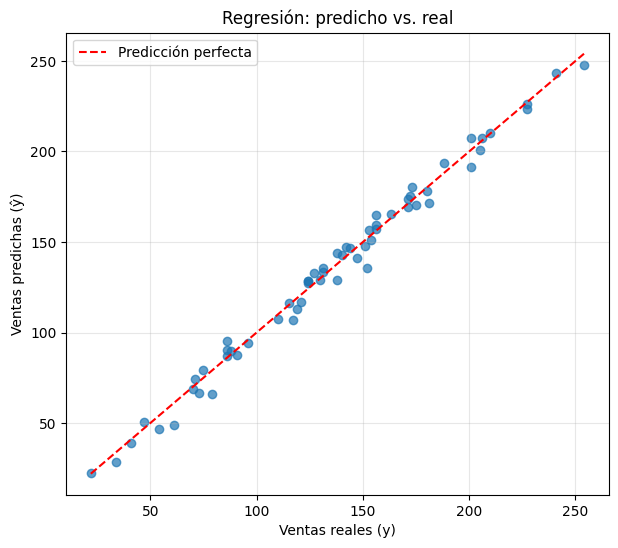

In [9]:
fig = plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Línea de predicción perfecta
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limites, limites, 'r--', label='Predicción perfecta')

plt.xlabel('Ventas reales (y)')
plt.ylabel('Ventas predichas (ŷ)')
plt.title('Regresión: predicho vs. real')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Probar el modelo con casos nuevos

Los dos casos de prueba del enunciado:

| Característica | Caso 1 | Caso 2 |
|---|---|---|
| DayOfWeek | Friday | Monday |
| Month | May | November |
| Temperature | 72.3 | 55.8 |
| Rainfall | 0.01 | 0.56 |

Antes de ejecutar: **¿cuál de los dos esperas que venda más helados?** Piénsalo y luego comprueba.

In [10]:
casos_nuevos = pd.DataFrame([
    {'DayOfWeek': 'Friday', 'Month': 'May',      'Temperature': 72.3, 'Rainfall': 0.01},
    {'DayOfWeek': 'Monday', 'Month': 'November', 'Temperature': 55.8, 'Rainfall': 0.56},
])

predicciones = modelo_regresion.predict(casos_nuevos)

for i, (_, caso) in enumerate(casos_nuevos.iterrows()):
    print(f"Caso {i+1}: {caso['DayOfWeek']}, {caso['Month']}, "
          f"{caso['Temperature']}°, lluvia {caso['Rainfall']} "
          f"→ {predicciones[i]:.0f} helados")

Caso 1: Friday, May, 72.3°, lluvia 0.01 → 130 helados
Caso 2: Monday, November, 55.8°, lluvia 0.56 → 41 helados


---

# Parte 2 · Clasificación: especies de pingüinos

Ahora el label no es un número sino una **clase**: 0 (Adelia), 1 (Gentoo) o 2 (Barbijo). Como hay tres clases posibles, es **clasificación multiclase**.

In [11]:
df_pinguinos = pd.read_csv('../datasets/penguins.csv')

print(df_pinguinos.shape)
print('\nDistribución de clases:')
print(df_pinguinos['Species'].value_counts().sort_index())
df_pinguinos.head()

(344, 5)

Distribución de clases:
Species
0    152
1    124
2     68
Name: count, dtype: int64


,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,NaN,NaN,NaN,NaN,0
4,36.7,19.3,193.0,3450.0,0


## Datos del mundo real: hay nulos

Antes de entrenar, siempre conviene comprobar si faltan valores. Este dataset **sí** tiene, aunque la app web nunca lo mencionó.

In [12]:
print('Nulos por columna:')
print(df_pinguinos.isnull().sum())

print('\nFilas afectadas:')
df_pinguinos[df_pinguinos.isnull().any(axis=1)]

Nulos por columna:
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64

Filas afectadas:


,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
3,NaN,NaN,NaN,NaN,0
271,NaN,NaN,NaN,NaN,1


Son dos filas a las que les faltan **todas** las medidas.

Aquí la decisión es fácil: no tiene sentido imputar cuatro features cuando no queda ninguna información de esa observación. Se descartan (`dropna`). Perder 2 filas de 344 es asumible.

Si en cambio faltara solo una medida de las cuatro, sí valdría la pena plantearse imputarla en vez de tirar la fila entera.

In [13]:
antes = len(df_pinguinos)
df_pinguinos = df_pinguinos.dropna()
print(f'{antes} → {len(df_pinguinos)} filas (se descartaron {antes - len(df_pinguinos)})')

344 → 342 filas (se descartaron 2)


## Preparar y entrenar

Todas las features son numéricas, así que no hace falta codificar nada. El algoritmo es **regresión logística** — recuerda que, pese al nombre, sirve para clasificación.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

label_p = 'Species'
features_p = ['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass']

Xp = df_pinguinos[features_p]
yp = df_pinguinos[label_p]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.3, random_state=RANDOM_STATE, stratify=yp
)

# StandardScaler: BodyMass está en miles y CulmenDepth en decenas.
# Sin escalar, la feature de mayor magnitud domina el cálculo.
modelo_clasificacion = Pipeline([
    ('escalado', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_clasificacion.fit(Xp_train, yp_train)
print(f'Entrenado con {len(Xp_train)} pingüinos, reservados {len(Xp_test)} para probar.')

Entrenado con 239 pingüinos, reservados 103 para probar.


## Evaluar: matriz de confusión

La diagonal son los aciertos. Todo lo que quede fuera indica qué especie se confundió con cuál.

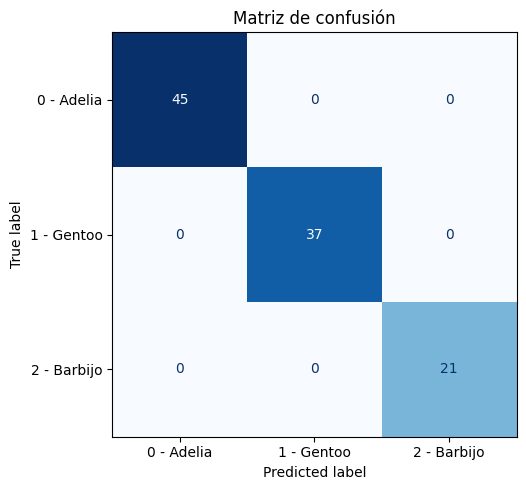

Exactitud global: 1.000


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

yp_pred = modelo_clasificacion.predict(Xp_test)

especies = ['0 - Adelia', '1 - Gentoo', '2 - Barbijo']
cm = confusion_matrix(yp_test, yp_pred)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=especies).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

print(f'Exactitud global: {accuracy_score(yp_test, yp_pred):.3f}')

## Métricas por clase

`classification_report` calcula precisión, recall y F1 **para cada clase** además del agregado — exactamente la tabla del Módulo 6.

Mira si alguna clase tiene métricas peores que las demás: el promedio global puede esconderlo.

In [16]:
print(classification_report(yp_test, yp_pred, target_names=especies, digits=3))

              precision    recall  f1-score   support

  0 - Adelia      1.000     1.000     1.000        45
  1 - Gentoo      1.000     1.000     1.000        37
 2 - Barbijo      1.000     1.000     1.000        21

    accuracy                          1.000       103
   macro avg      1.000     1.000     1.000       103
weighted avg      1.000     1.000     1.000       103



> **Si te salió 1.000 en todo, no te asustes.** Un resultado perfecto normalmente es señal de alarma (suele indicar que el label se coló entre las features, o que estás evaluando con los mismos datos del entrenamiento). Aquí no es el caso: este dataset es genuinamente fácil de separar — las tres especies tienen medidas bastante distintas entre sí.
>
> Para comprobarlo tú mismo, grafica `FlipperLength` contra `CulmenDepth` coloreando por especie y mira si los grupos se solapan.

## Probar con casos nuevos

| Característica | Caso 1 | Caso 2 |
|---|---|---|
| CulmenLength | 45.2 | 46.9 |
| CulmenDepth | 15.4 | 16.7 |
| FlipperLength | 219 | 189 |
| BodyMass | 4753 | 3645 |

Además de la clase predicha, aquí se imprimen las **probabilidades de cada clase** — eso es lo que el modelo calcula realmente antes de quedarse con la más alta.

In [17]:
casos_pinguinos = pd.DataFrame([
    {'CulmenLength': 45.2, 'CulmenDepth': 15.4, 'FlipperLength': 219, 'BodyMass': 4753},
    {'CulmenLength': 46.9, 'CulmenDepth': 16.7, 'FlipperLength': 189, 'BodyMass': 3645},
])

clases_pred = modelo_clasificacion.predict(casos_pinguinos)
probabilidades = modelo_clasificacion.predict_proba(casos_pinguinos)

for i in range(len(casos_pinguinos)):
    probs = ', '.join(f'{p:.3f}' for p in probabilidades[i])
    print(f'Caso {i+1} → clase {clases_pred[i]} ({especies[clases_pred[i]]})')
    print(f'         probabilidades [clase0, clase1, clase2]: [{probs}]\n')

Caso 1 → clase 1 (1 - Gentoo)
         probabilidades [clase0, clase1, clase2]: [0.008, 0.985, 0.007]

Caso 2 → clase 2 (2 - Barbijo)
         probabilidades [clase0, clase1, clase2]: [0.030, 0.015, 0.954]



---

# Parte 3 · Clustering: segmentación de clientes

Cambio de paradigma: **no hay label**. El dataset solo trae features (`AverageSpend`, `AverageFrequency`) y el objetivo es descubrir grupos que no sabíamos que existían.

In [18]:
df_clientes = pd.read_csv('../datasets/customers.csv')

print(df_clientes.shape)
print(df_clientes.columns.tolist())
df_clientes.head()

(40, 3)
['Name', 'AverageSpend', 'AverageFrequency']


,Name,AverageSpend,AverageFrequency
0,Customer1,88.0,48.0
1,Customer2,95.0,45.5
2,Customer3,92.0,46.8
3,Customer4,85.0,49.2
4,Customer5,90.0,44.0


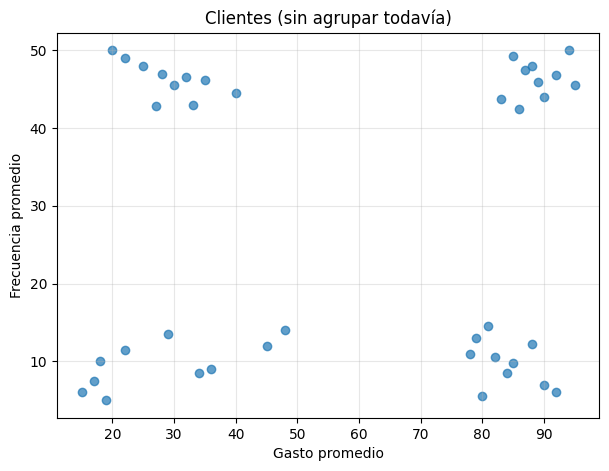

In [19]:
features_c = ['AverageSpend', 'AverageFrequency']
Xc = df_clientes[features_c]

fig = plt.figure(figsize=(7,5))
plt.scatter(Xc['AverageSpend'], Xc['AverageFrequency'], alpha=0.7)
plt.xlabel('Gasto promedio')
plt.ylabel('Frecuencia promedio')
plt.title('Clientes (sin agrupar todavía)')
plt.grid(alpha=0.3)
plt.show()

## Encontrar el número óptimo de clústeres

En la app web esto era la opción "Automático". Por dentro, lo que se hace es probar varios valores de `k` y quedarse con el que mejor separe los grupos.

Aquí se usa el **coeficiente de silueta** (visto en el Módulo 7): un valor entre -1 y 1, donde más cerca de 1 significa mejor separación.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Escalar: gasto y frecuencia están en escalas distintas,
# y K-Means se basa en distancias.
escalador_c = StandardScaler()
Xc_escalado = escalador_c.fit_transform(Xc)

resultados = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(Xc_escalado)
    silueta = silhouette_score(Xc_escalado, etiquetas)
    resultados.append((k, silueta, km.inertia_))
    print(f'k = {k}  →  silueta = {silueta:.3f}')

k_optimo = max(resultados, key=lambda r: r[1])[0]
print(f'\nMejor k según la silueta: {k_optimo}')

k = 2  →  silueta = 0.503
k = 3  →  silueta = 0.635
k = 4  →  silueta = 0.810
k = 5  →  silueta = 0.767
k = 6  →  silueta = 0.655
k = 7  →  silueta = 0.543

Mejor k según la silueta: 4


### El método del codo

Otra forma de decidir `k`: graficar la inercia (qué tan compactos son los grupos) y buscar el punto donde la curva deja de mejorar bruscamente — el "codo".

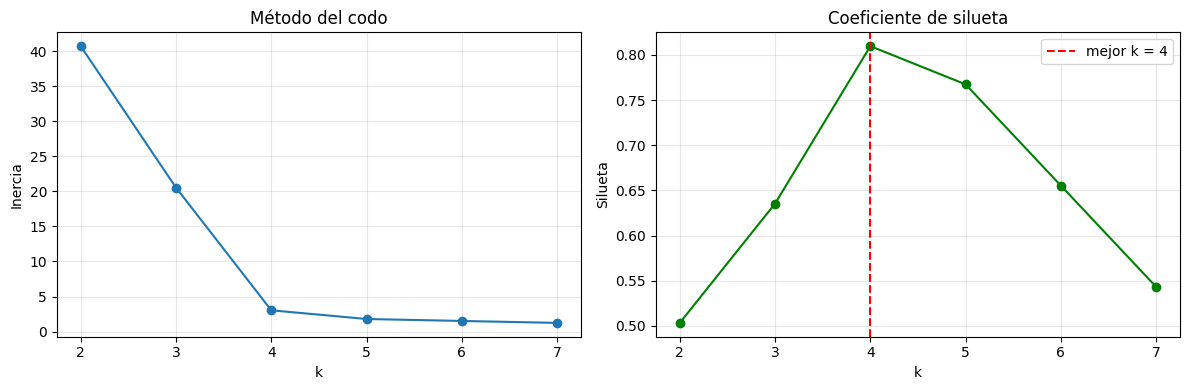

In [21]:
ks = [r[0] for r in resultados]
inercias = [r[2] for r in resultados]
siluetas = [r[1] for r in resultados]

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(ks, inercias, 'o-')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inercia')
ax[0].set_title('Método del codo')
ax[0].grid(alpha=0.3)

ax[1].plot(ks, siluetas, 'o-', color='green')
ax[1].axvline(k_optimo, color='red', linestyle='--', label=f'mejor k = {k_optimo}')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silueta')
ax[1].set_title('Coeficiente de silueta')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Entrenar el modelo final y ver los grupos

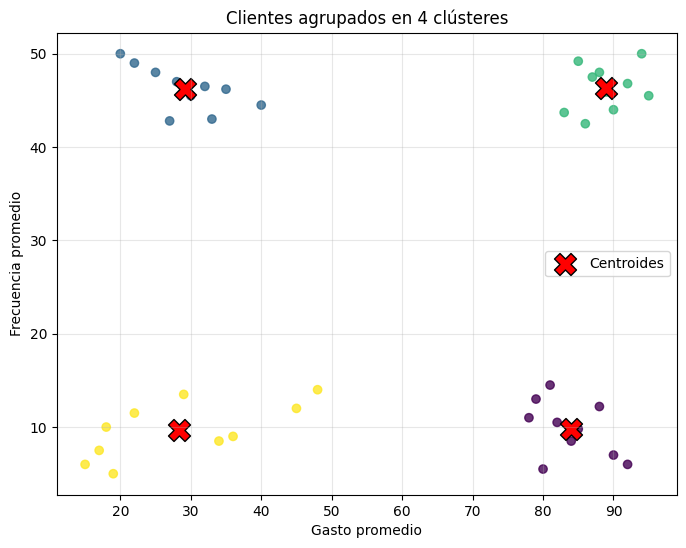

         AverageSpend  AverageFrequency
Cluster                                
0                83.9              9.80
1                29.2             46.25
2                88.9             46.31
3                28.3              9.70


In [22]:
modelo_clustering = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
grupos = modelo_clustering.fit_predict(Xc_escalado)

df_clientes['Cluster'] = grupos

# Los centroides están en escala transformada: hay que devolverlos a las unidades originales
centroides = escalador_c.inverse_transform(modelo_clustering.cluster_centers_)

fig = plt.figure(figsize=(8,6))
plt.scatter(Xc['AverageSpend'], Xc['AverageFrequency'], c=grupos, cmap='viridis', alpha=0.8)
plt.scatter(centroides[:,0], centroides[:,1], marker='X', s=250,
            c='red', edgecolors='black', label='Centroides')
plt.xlabel('Gasto promedio')
plt.ylabel('Frecuencia promedio')
plt.title(f'Clientes agrupados en {k_optimo} clústeres')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(df_clientes.groupby('Cluster')[features_c].mean().round(2))

### Interpretar los grupos

Esta es la parte que **ningún algoritmo hace por ti**. K-Means devuelve números (0, 1, 2...) sin significado. Darles sentido de negocio es trabajo humano.

Mira la tabla de promedios por clúster: ¿cómo describirías cada grupo? ("gasta mucho pero viene poco", "cliente frecuente de compra pequeña"...)

Recuerda del Módulo 3: si luego etiquetas esos grupos a mano, puedes usarlos como labels para entrenar un **clasificador** que asigne clientes nuevos automáticamente.

## Probar con casos nuevos

| Característica | Caso 1 | Caso 2 |
|---|---|---|
| AverageSpend | 21.0 | 46.9 |
| AverageFrequency | 105.0 | 2.0 |

In [23]:
casos_clientes = pd.DataFrame([
    {'AverageSpend': 21.0, 'AverageFrequency': 105.0},
    {'AverageSpend': 46.9, 'AverageFrequency': 2.0},
])

# Misma transformación que se aplicó al entrenar
casos_escalados = escalador_c.transform(casos_clientes)
grupos_pred = modelo_clustering.predict(casos_escalados)

for i, (_, caso) in enumerate(casos_clientes.iterrows()):
    print(f"Caso {i+1}: gasto {caso['AverageSpend']}, frecuencia {caso['AverageFrequency']} "
          f"→ clúster {grupos_pred[i]}")

Caso 1: gasto 21.0, frecuencia 105.0 → clúster 1
Caso 2: gasto 46.9, frecuencia 2.0 → clúster 3


---

# Resumen

Entrenaste tres modelos, uno de cada rama de la taxonomía del curso:

| | Regresión | Clasificación | Clustering |
|---|---|---|---|
| **Aprendizaje** | Supervisado | Supervisado | No supervisado |
| **¿Hay label?** | Sí, numérico | Sí, categórico | No |
| **Algoritmo** | Regresión lineal | Regresión logística | K-Means |
| **Se evalúa con** | MAE, MSE, RMSE, R² | Matriz de confusión, exactitud, precisión, recall, F1 | Silueta, inercia |
| **Métrica clave** | ¿Cuánto me equivoco? | ¿Acierto la clase? | ¿Están bien separados? |

Dos cosas que la app web hacía en silencio y aquí quedaron a la vista:

1. **Codificar variables de texto** (one-hot para `DayOfWeek` y `Month`). Sin eso, el modelo de helados ni siquiera arranca.
2. **Escalar las features** antes de K-Means y de la regresión logística. Como ambos se basan en distancias o magnitudes, una feature en miles (`BodyMass`) aplastaría a otra en decenas (`CulmenDepth`).

## Para seguir explorando

En `../datasets/` quedaron dos archivos que el ejercicio no usa: `diabetes.csv` y `home-rental.csv`. Buen material para repetir el proceso por tu cuenta:

- `diabetes.csv` → clasificación **binaria** (la columna `Diabetic` es 0/1). Aquí sí podrías dibujar una curva ROC y jugar con el umbral.
- `home-rental.csv` → regresión (predecir `rent_amount`).